# COMPUTATIONAL MACRO     -     PROBLEM SET 2


In [14]:
## 0. Setting up 
#################################################################
using Printf
using Plots
using Statistics

Base.@kwdef struct EconomicParameters
    α::Float64 = 0.3          # capital share
    β::Float64 = 0.96         # discount factor
    δ::Float64 = 1.0          # depreciation rate 
    γ::Float64 = 1.0          # CRRA coefficient
end

Base.@kwdef struct NumericalParameters
    nk::Int = 200             # number of points on the capital grid, N
    kmin_rel::Float64 = 0.1   # lower grid bound, relative to k*
    kmax_rel::Float64 = 2.0   # upper grid bound, relative to k*
    spacing::Symbol = :linear # :linear or :log
    crit::Float64 = 1e-6      # convergence tolerance, ε
    maxiter::Int = 5000       # iteration cap
end

par = EconomicParameters()
mpar = NumericalParameters()

NumericalParameters(200, 0.1, 2.0, :linear, 1.0e-6, 5000)

## 2.1 With and without closed form

In [15]:
## Rewriting to generalised problem 
#################################################################
function vfi(par, mpar)
    # 1. Defining grid 
    kstar = (par.α/(1/par.β - 1 + par.δ))^(1/(1-par.α)) # CHANGED
    kmin, kmax = mpar.kmin_rel * kstar, mpar.kmax_rel * kstar
    @printf("\n \nk* = %.4f, grid bounds %.4f to %.4f\n", kstar, kmin, kmax)

    k = mpar.spacing == :linear ? collect(range(kmin, kmax, length = mpar.nk)) :
                                exp.(range(log(kmin), log(kmax), length = mpar.nk))

    # 2. Utility function
    util(c) = par.γ==1 ? log(c) : (c^(1-par.γ)-1)/(1-par.γ) # CHANGED

    # 3. Preparing tables for C and U  
    # Output and consumption 
    Y = k .^ par.α                   # output k_i^α
    C = Y .+ (1-par.δ).*k .- k'      # CHANGED   # rely on automatic broadcasting via transpose   # consumption for every (state, choice) pair

    # Reward matrix U
    U = fill(-Inf, size(C))
    U[C .> 0] = util.(C[C .> 0])
    println("no NaN in U: ", !any(isnan, U))

    # 4. Loop for value function iteration 
    timer  = time()
    v      = zeros(mpar.nk)                      # initial guess
    g      = ones(Int, mpar.nk)                  # the policy as grid indices
    distVF = [Inf]                               # distances d_n, one per iteration
    iterVF = 0                                   # iteration counter

    @printf("Value function iteration with parameters alpha= %g, beta= %g, gamma= %g, delta= %g, N= %d, crit= %.0e \n", par.α, par.β, par.γ, par.δ, mpar.nk, mpar.crit)
    while distVF[end] > mpar.crit && iterVF < mpar.maxiter  
        M    = U .+ par.β .* v'                # RHS of Bellman
        vals, idx = findmax(M, dims = 2)       # row-wise max 
        vnew = vec(vals)                       # update value fct 
        g    = vec(getindex.(idx, 2))          
        dd   = maximum(abs.(vnew .- v))        # update distance
        v    = vnew                            # update v 
        iterVF += 1                            # update iteration counter 
        push!(distVF, dd)                      # append distance
    end
    time_vfi = time() - timer
    @printf("Finished with iterations: %d, final distance: %.3e, time: %.3f s\n", iterVF, distVF[end], time_vfi)

    # Implied optimal items 
    kprime = k[g]
    c = Y .+ (1-par.δ).*k .- kprime
    cprime = c[g]

    # 5. Sanity checks
    # Convergence check 
    if distVF[end] > mpar.crit
        error("not converged: the iteration cap was hit")
    end

    # Boundary 
    println("policy at the lowest grid point:  ", count(g .== 1), " states")
    println("policy at the highest grid point: ", count(g .== mpar.nk), " states")

    # Contraction rate 
    @printf("last ratio d_n / d_(n-1): %.4f   (β = %.2f)\n", distVF[end] / distVF[end-1], par.β)

    # Return 
    return(; kstar=kstar, v=v, g=g, k=k, kprime=kprime, c=c, cprime=cprime, iterations=iterVF, distance=distVF, time_vfi=time_vfi, par, mpar)
end


vfi (generic function with 1 method)

### 2.1 a) Changes in VFI through generalisation

To generalise the VFI function to the model with depreciation and general CRRA utility, I had to change the following parts: (also marked in the code above)
- definition of the steady state k*
- definition of the utility function
- definition of consumption

Everything else remains the same.

### 2.1 b) Testing generalisation against simpler case

In [3]:
# Benchmark: closed form 
results_21b = vfi(par, mpar) # can run with default values
F = results_21b.par.α / (1 - results_21b.par.α * results_21b.par.β)
E = (log(1 - results_21b.par.α * results_21b.par.β) + results_21b.par.β * F * log(par.α * results_21b.par.β)) / (1 - results_21b.par.β)
policy_error = maximum(abs.(results_21b.k[results_21b.g] .- results_21b.par.α * results_21b.par.β .* results_21b.k .^ results_21b.par.α))
value_error = maximum(abs.(results_21b.v .- (E .+ F .* log.(results_21b.k))))
@printf("Largest policy error: %.1e, largest value error: %.1e \n", policy_error, value_error)



 
k* = 0.1689, grid bounds 0.0169 to 0.3379
no NaN in U: true
Value function iteration with parameters alpha= 0.3, beta= 0.96, gamma= 1, delta= 1, N= 200, crit= 1e-06 
Finished with iterations: 337, final distance: 9.792e-07, time: 1.090 s
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states
last ratio d_n / d_(n-1): 0.9600   (β = 0.96)
Largest policy error: 9.4e-04, largest value error: 2.4e-05 


We see that the generalised version works.

### 2.1 c) Euler equation error 

In [17]:
function EEerr(sol)
    R = (sol.par.α .* sol.kprime .^ (sol.par.α - 1) .+ 1 .- sol.par.δ) # could also use sol.k[sol.g]=sol.kprime, but inconvient for check that follows
    e = 1 .- (sol.par.β .* R) .^ (-1/sol.par.γ) .* sol.cprime ./ sol.c # same here with sol.c[sol.g]=sol.cprime
    max = maximum(abs.(e))
    grpt = argmax(abs.(e))
    return(; e=e, max=max, grpt=grpt, maxpct=100*max)
end

g(k, alpha, beta) = alpha * beta .* k .^alpha
check = (par, mpar, 
        k=results_21b.k, 
        kprime=g(results_21b.k, par.α, par.β), 
        c = results_21b.k .^ par.α .- g(results_21b.k, par.α, par.β), # k*α-g(k)
        cprime = g(results_21b.k, par.α, par.β) .^par.α .- g(g(results_21b.k, par.α, par.β), par.α, par.β)) # g(k)*^α - g(g(k))

eee_21c = EEerr(check)
@printf("Euler equation error with closed form policy: %e  \n", eee_21c.max)


Euler equation error with closed form policy: 6.661338e-16  


We see that the error is (almost) zero - the remaining error stems from floating point rounding.

### 2.1. d)

In [5]:
eee_21d = EEerr(results_21b)

@printf("The maximum absolute deviation of consumption from the consumption prescribed by the Euler equation given tomorrow's consumption occurs at index %d and amounts to %.2f percent.\n", eee_21d.grpt, eee_21d.maxpct)


The maximum absolute deviation of consumption from the consumption prescribed by the Euler equation given tomorrow's consumption occurs at index 2 and amounts to 1.17 percent.


### 2.1. e)


 
k* = 2.9208, grid bounds 0.2921 to 5.8416
no NaN in U: true
Value function iteration with parameters alpha= 0.3, beta= 0.96, gamma= 2, delta= 0.1, N= 200, crit= 1e-06 
Finished with iterations: 226, final distance: 9.804e-07, time: 0.082 s
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states
last ratio d_n / d_(n-1): 0.9600   (β = 0.96)
The maximum absolute deviation of consumption from the consumption prescribed by the Euler equation given tomorrow's consumption occurs at index 1 and amounts to 4.56 percent .
The mean of log10 of the absolute value of all e's over the grid is -2.16.


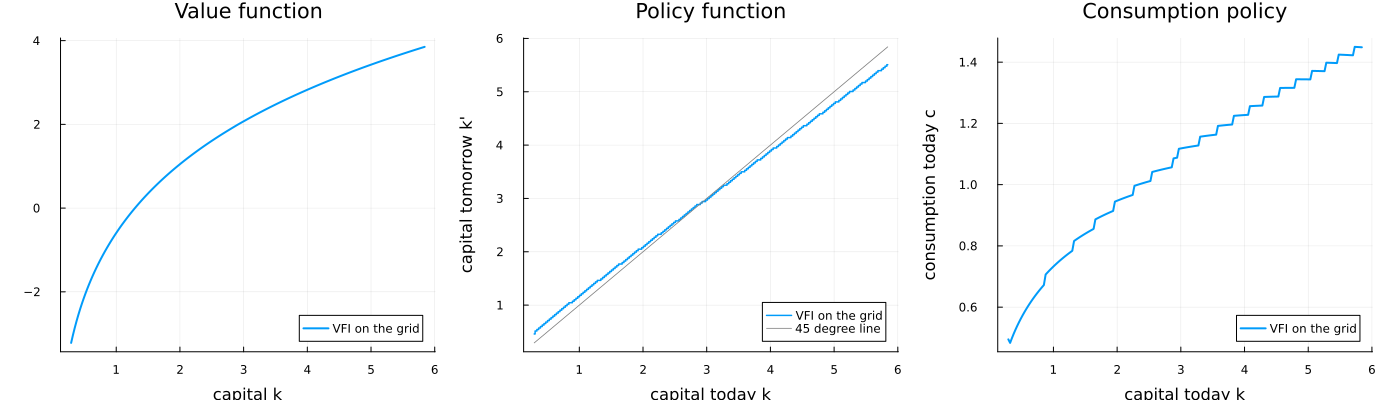

In [6]:
par2 = EconomicParameters(γ=2.0, δ=0.1)
results_21e = vfi(par2, mpar)
eee_21e = EEerr(results_21e)
@printf("The maximum absolute deviation of consumption from the consumption prescribed by the Euler equation given tomorrow's consumption occurs at index %d and amounts to %.2f percent .\n", eee_21e.grpt, eee_21e.maxpct)

mean_eee21e = mean(log10.(abs.(eee_21e.e)))
@printf("The mean of log10 of the absolute value of all e's over the grid is %.2f.\n", mean_eee21e)

# Plotting value, policy and consumption function 
p21e_val = plot(results_21e.k, results_21e.v, linewidth = 2, label = "VFI on the grid", legend = :bottomright,
          xlabel = "capital k", title = "Value function")

p21e_pol = plot(results_21e.k, results_21e.kprime, seriestype = :stepmid, linewidth = 1.5, label = "VFI on the grid", legend = :bottomright,
          xlabel = "capital today k", ylabel = "capital tomorrow k'", title = "Policy function")
plot!(p21e_pol, results_21e.k, results_21e.k, color = :gray, linewidth = 0.8, label = "45 degree line")

p21e_c = plot(results_21e.k, results_21e.c, linewidth = 2, label = "VFI on the grid", legend = :bottomright, 
            xlabel = "capital today k", ylabel = "consumption today c", title = "Consumption policy")

plot(p21e_val, p21e_pol, p21e_c, layout = (1, 3), size = (1400, 400), margin = 5Plots.mm)


The mean of the log of the error gives us the average ordner of magnitude of th error.

### 2.1. f)


In [18]:
idx = argmin(abs.(results_21e.kprime .- results_21e.k))
crossing = results_21e.k[idx]

2.885596154185609

The policy crosses the 45° line shortly before k=3, at roughly 2.89 - this is very close to the computed k*=2.9208.

The Euler equation error is the largest at the first grid point.
This results from two effects:
First, given that we have equidistant spacing on the grid, the size of the jump between grid points relative to the grid point value is largest at the lower end of the grid.
This means that rounding to the nearest grid point introduces a larger error at low grid points.
Second, at low k, c is low as well. At low c, MU is steep, so small errors in k' due to working on the grid lead to larger changes in MU. As the Euler equation is based on marginal utility (across periods), it is affected such that we see a larger error.

## 2.2 Simulation, the cost of the grid, and risk aversion

### 2.2. a)

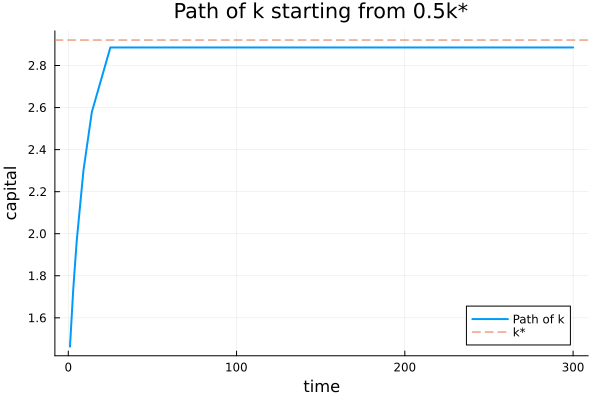

In [8]:
function simulation(sol, nperiods, k0_par)
    # Initialise 
    i_kt = ones(Int, nperiods)
    i_kt[1] = argmin(abs.(sol.k .- k0_par*(sol.kstar))) # initialise at grid point closest to 0.5*kstar
    
    # Loop over periods
    for t in 2:nperiods
        i_kt[t] = sol.g[i_kt[t-1]]
    end

    # Convert to capital values 
    kt = sol.k[i_kt]
    t = 1:nperiods

    err = sol.kstar - kt[end]

    return(; i_kt=i_kt, kt=kt, t=t, err=err)
end

sim_22a = simulation(results_21e, 300, 0.5)

p22a = plot(sim_22a.t, sim_22a.kt, linewidth = 2, label = "Path of k", legend = :bottomright,
          xlabel = "time", ylabel = "capital", title = "Path of k starting from 0.5k*")
hline!(p22a, [results_21e.kstar], linestyle = :dash, label = "k*")


In [20]:
@printf("The path settles at %.4f, which is %.4f away from the true k*.", sim_22a.kt[end], sim_22a.err)

The path settles at 2.8856, which is 0.0352 away from the true k*.

### 2.2. b) Changing grid granularity

In [10]:
Nset = [50, 200, 800]

rows = []
for n in Nset
    mpar_n = NumericalParameters(nk = n)   # reuse defaults, override nk
    sol = vfi(par2, mpar_n)
    eee = EEerr(sol)
    sim = simulation(sol, 300, 0.5)

    push!(rows, (
        N        = n,
        spacing  = sol.k[2] - sol.k[1],     # grid spacing (only exact if :linear)
        iterations = sol.iterations,
        runtime  = sol.time_vfi,
        maxe     = eee.max,
        settle   = sim.kt[end],             # where the path settles
    ))
end

@printf("%-6s %-12s %-10s %-10s %-12s %-10s\n", "N", "spacing", "iters", "time (s)", "max|e_i|", "settle")
for r in rows
    @printf("%-6d %-12.5f %-10d %-10.3f %-12.3e %-10.4f\n",
            r.N, r.spacing, r.iterations, r.runtime, r.maxe, r.settle)
end



 
k* = 2.9208, grid bounds 0.2921 to 5.8416
no NaN in U: true
Value function iteration with parameters alpha= 0.3, beta= 0.96, gamma= 2, delta= 0.1, N= 50, crit= 1e-06 
Finished with iterations: 230, final distance: 9.667e-07, time: 0.003 s
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states
last ratio d_n / d_(n-1): 0.9600   (β = 0.96)

 
k* = 2.9208, grid bounds 0.2921 to 5.8416
no NaN in U: true
Value function iteration with parameters alpha= 0.3, beta= 0.96, gamma= 2, delta= 0.1, N= 200, crit= 1e-06 
Finished with iterations: 226, final distance: 9.804e-07, time: 0.068 s
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states
last ratio d_n / d_(n-1): 0.9600   (β = 0.96)

 
k* = 2.9208, grid bounds 0.2921 to 5.8416
no NaN in U: true
Value function iteration with parameters alpha= 0.3, beta= 0.96, gamma= 2, delta= 0.1, N= 800, crit= 1e-06 
Finished with iterations: 226, final distance: 9.622e-07, time: 0.841 s
policy a

We see from the table that N quadruples by each row, while the iteration count stays roughly the same. The run time grows by a factor of more than 10, while the maximum absolute Euler equation error falls by factor 4.

Does this match the orders in N? Run time is mostly determined by the number of the k-k' combinations that have to be checked in the row-wise maximisation of M. The number of possible combinations equals N². So it makes sense that runtime grows much more quickly than N. In fact, while N grows by 4 each round, the runtime should grow by around 4²=16. The Euler equation error however should fall as there are more grid points. Roughly speaking, if one has twice the number of grid points, then the distance to the next grid point and hence the maximum error from being on the grid is halfed. This is reflected in the table by the error being divide by 4 in each round.

### 2.2. c) Run time vs error

In [33]:
N4 = ceil(rows[1].maxe/(10^(-4)) * rows[1].N)
@printf("One would need at least %d observations to bring max_i|e_i| below 10e-4.\n", N4)
runtime = rows[1].runtime * (N4/rows[1].N)^2/3600
@printf("This would take %.5f hours.\n", runtime)

One would need at least 82660 observations to bring max_i|e_i| below 10e-4.
This would take 2.55469 hours.


### 2.2. d) Solving for different gammas


 
k* = 2.9208, grid bounds 0.2921 to 5.8416
no NaN in U: true
Value function iteration with parameters alpha= 0.3, beta= 0.96, gamma= 1, delta= 0.1, N= 800, crit= 1e-06 
Finished with iterations: 156, final distance: 9.735e-07, time: 0.645 s
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states
last ratio d_n / d_(n-1): 0.9600   (β = 0.96)

 
k* = 2.9208, grid bounds 0.2921 to 5.8416
no NaN in U: true
Value function iteration with parameters alpha= 0.3, beta= 0.96, gamma= 2, delta= 0.1, N= 800, crit= 1e-06 
Finished with iterations: 226, final distance: 9.622e-07, time: 0.861 s
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states
last ratio d_n / d_(n-1): 0.9600   (β = 0.96)

 
k* = 2.9208, grid bounds 0.2921 to 5.8416
no NaN in U: true
Value function iteration with parameters alpha= 0.3, beta= 0.96, gamma= 5, delta= 0.1, N= 800, crit= 1e-06 
Finished with iterations: 247, final distance: 9.657e-07, time: 0.938 s
policy 

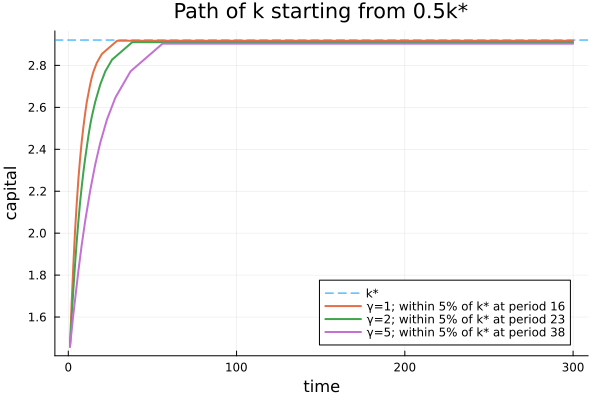

In [34]:
gset = [1, 2, 5]
mpar22d = NumericalParameters(nk=800)

r22d = []
for g in gset 
    par22d = EconomicParameters(δ=0.1, γ=g)
    results = vfi(par22d, mpar22d)
    sim = simulation(results, 300, 0.5)
    t5 = findfirst(t -> abs(sim.kt[t]-results.kstar)/results.kstar <= 0.05, 1:length(sim.kt))

    push!(r22d, (
        gamma=g,
        delta=results.par.δ,
        alpha=results.par.α,
        t=sim.t,
        kstar=results.kstar,
        kt=sim.kt,
        t5=t5
    ))
end

p22d = hline([r22d[1].kstar], linestyle=:dash, label="k*", legend=:bottomright,
             xlabel="time", ylabel="capital", title="Path of k starting from 0.5k*")

for g in 1:3 
    gam = r22d[g].gamma
    pct5 = r22d[g].t5
    plot!(p22d, r22d[g].t, r22d[g].kt, linewidth = 2, label = "γ=$gam; within 5% of k* at period $pct5")
end 
p22d


### 2.2 e) Convergence to steady state across CRRA coefficients

For lower values of $\gamma$, the household converges faster. The table below shows that the savings rate decreases in $\gamma$ - which is in line with faster convergence. The IES decreases in $\gamma$, i.e. households with a larger coefficient of relative risk aversion react less to changes in the return to savings. They have a stronger preference for a smooth consumption, so they are less willing to cut consumption today to achieve the steady state faster despite the high returns to capital possible due to the low capital we start out from.

In [13]:
r22e = []
for g in 1:3 
    push!(r22e, (
        gamma=r22d[g].gamma,
        IES = 1/r22d[g].gamma ,
        sr = (r22d[g].kt[2] - (1-r22d[g].delta) * r22d[g].kt[1]) / (r22d[g].kt[1] ^ r22d[g].alpha)
    ))
end

@printf("%-6s %-12s %-10s\n", "γ", "IES", "Savings rate")
for r in r22e
    @printf("%-6d %-12.1f %.5f \n", r.gamma, r.IES, r.sr)
end

γ      IES          Savings rate
1      1.0          0.31631 
2      0.5          0.25430 
5      0.2          0.19848 
